# Ablation — GPTQ vs Naive Quantization on 2D Matrices

Compares GPTQ (Hessian-based error compensation) against naive round-to-nearest quantization at different bitwidths.

| config | method | bitwidth |
|---|---|---|
| `naive_int8` | baseline naive rounding | int8 (±127) |
| `naive_int6` | baseline naive rounding | int6 (±31) |
| `naive_int4` | baseline naive rounding | int4 (±7) |
| `gptq_int8` | GPTQ | int8 (±127) |
| `gptq_int6` | GPTQ | int6 (±31) |
| `gptq_int4` | GPTQ | int4 (±7) |

## Goal

This ablation answers two questions:
1. **How much BPB does GPTQ recover** compared to naive rounding at the same bitwidth?
2. **Does GPTQ enable lower bitwidths?** Specifically, can GPTQ at int6 match or beat naive at int8?

Training is identical across all runs — only the post-training quantization method and bitwidth change. GPTQ uses 128 calibration sequences from the validation set and block size 128.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib, utils as utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

BITS_ORDER = [8, 6, 4]
BITS_LABELS = {8: "int8", 6: "int6", 4: "int4"}

# Colors: naive in blue tones, GPTQ in green tones
NAIVE_COLOR = PALETTE[0]
GPTQ_COLOR  = PALETTE[2]

## Original Baseline (3 seeds, reference)

In [6]:
BASELINE_PREFIX = "golf_baseline_antonio_new"

baseline_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
))

baseline_rows = []
for run in baseline_runs:
    s = run.summary._json_dict
    baseline_rows.append({
        "seed":             run.config.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
BASE_BPB_MEAN  = df_base["final_val_bpb"].mean()
BASE_BPB_STD   = df_base["final_val_bpb"].std()
BASE_SIZE_MEAN = df_base["quant_file_bytes"].mean()

print("=" * 55)
print("ORIGINAL BASELINE  (3 seeds)")
print("=" * 55)
print(df_base.to_string(index=False))
print(f"\nfinal_val_bpb : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print(f"file size     : {BASE_SIZE_MEAN / 1e6:.2f} MB")
print("=" * 55)

ORIGINAL BASELINE  (3 seeds)
 seed  final_val_bpb  final_val_loss  quant_file_bytes
   42       1.311465        2.214354          15782427
  123       1.309002        2.210195          15785894
 1337       1.309833        2.211598          15776355

final_val_bpb : 1.3101 ± 0.0013
file size     : 15.78 MB


## Fetch Ablation Runs

In [7]:
# --- Fetch naive (2D matrices) runs ---
NAIVE_PREFIX = "golf_2d_matrices_quantization_ablation"

naive_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{NAIVE_PREFIX}"}},
))

naive_rows = []
for run in naive_runs:
    s   = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", 8)

    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    naive_rows.append({
        "run_name":         run.name,
        "method":           "naive",
        "quant_bits":       bits,
        "seed":             cfg.get("seed"),
        "fp32_val_bpb":     fp32_bpb,
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_naive = pd.DataFrame(naive_rows)
print(f"Fetched {len(df_naive)} naive runs.")
df_naive

Fetched 9 naive runs.


,run_name,method,quant_bits,seed,fp32_val_bpb,final_val_bpb,final_val_loss,quant_file_bytes
0,golf_2d_matrices_quantization_ablation_seed1337,naive,8,1337,1.306432,1.310132,2.212102,15768886
1,golf_2d_matrices_quantization_ablation_seed42,naive,8,42,1.307871,1.311658,2.214679,15775590
2,golf_2d_matrices_quantization_ablation_seed123,naive,8,123,1.305577,1.309140,2.210427,15790397
3,golf_2d_matrices_quantization_ablation_int6_se...,naive,6,1337,1.306064,1.362489,2.300505,11896098
4,golf_2d_matrices_quantization_ablation_int6_se...,naive,6,42,1.306980,1.364526,2.303944,11905424
5,golf_2d_matrices_quantization_ablation_int6_se...,naive,6,123,1.304984,1.366342,2.307011,11903307
6,golf_2d_matrices_quantization_ablation_int4_se...,naive,4,1337,1.305906,2.259454,3.814994,7841982
7,golf_2d_matrices_quantization_ablation_int4_se...,naive,4,42,1.306976,2.215550,3.740863,7846052
8,golf_2d_matrices_quantization_ablation_int4_se...,naive,4,123,1.305626,2.245742,3.791842,7847991


In [8]:
# --- Fetch GPTQ runs ---
GPTQ_PREFIX = "GPTQ_MATRICES"

gptq_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{GPTQ_PREFIX}"}},
))

gptq_rows = []
for run in gptq_runs:
    s   = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", cfg.get("quant_bits", 8))

    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    gptq_rows.append({
        "run_name":         run.name,
        "method":           "gptq",
        "quant_bits":       bits,
        "seed":             cfg.get("seed"),
        "fp32_val_bpb":     fp32_bpb,
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_gptq = pd.DataFrame(gptq_rows)
print(f"Fetched {len(df_gptq)} GPTQ runs.")
df_gptq

Fetched 9 GPTQ runs.


,run_name,method,quant_bits,seed,fp32_val_bpb,final_val_bpb,final_val_loss,quant_file_bytes
0,GPTQ_MATRICES_seed1337,gptq,6,1337,1.306296,1.364889,2.304558,11896932
1,GPTQ_MATRICES_seed42,gptq,6,42,1.308099,1.367217,2.308489,11897277
2,GPTQ_MATRICES_seed123,gptq,6,123,1.305630,1.362232,2.300072,11906305
3,GPTQ_MATRICES_seed1337,gptq,4,1337,1.306326,2.105418,3.554910,7850221
4,GPTQ_MATRICES_seed42,gptq,4,42,1.307331,2.203581,3.720654,7855540
5,GPTQ_MATRICES_seed123,gptq,4,123,1.305189,2.144190,3.620376,7868664
6,GPTQ_MATRICES_seed1337,gptq,8,1337,1.306735,1.310361,2.212490,15767242
7,GPTQ_MATRICES_seed42,gptq,8,42,1.307448,1.311094,2.213727,15773851
8,GPTQ_MATRICES_seed123,gptq,8,123,1.305504,1.309179,2.210494,15783429


In [9]:
# --- Combine, compute deltas, and aggregate across seeds ---
df = pd.concat([df_naive, df_gptq], ignore_index=True)
df["delta_bpb"] = df["final_val_bpb"] - df["fp32_val_bpb"]

df = (
    df.assign(bits_order=df["quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)}))
    .sort_values(["bits_order", "method", "seed"])
    .reset_index(drop=True)
    .drop(columns="bits_order")
)

def std_or_zero(s):
    v = s.std(ddof=1)
    return 0.0 if pd.isna(v) else float(v)

df_stats = (
    df.groupby(["method", "quant_bits"], as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        final_val_bpb_mean=("final_val_bpb", "mean"),
        final_val_bpb_std=("final_val_bpb", std_or_zero),
        delta_bpb_mean=("delta_bpb", "mean"),
        delta_bpb_std=("delta_bpb", std_or_zero),
        quant_file_mb_mean=("quant_file_bytes", lambda x: x.mean() / 1e6),
        quant_file_mb_std=("quant_file_bytes", lambda x: std_or_zero(x) / 1e6),
    )
    .assign(bits_order=lambda d: d["quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)}))
    .sort_values(["bits_order", "method"])
    .reset_index(drop=True)
    .drop(columns="bits_order")
)

stats_naive = df_stats[df_stats["method"] == "naive"].set_index("quant_bits")
stats_gptq = df_stats[df_stats["method"] == "gptq"].set_index("quant_bits")

print("Aggregated means ± std across seeds")
df_stats

Aggregated means ± std across seeds


,method,quant_bits,n_seeds,final_val_bpb_mean,final_val_bpb_std,delta_bpb_mean,delta_bpb_std,quant_file_mb_mean,quant_file_mb_std
0,gptq,8,3,1.310212,0.000966,0.003649,0.000024,15.774841,0.008139
1,naive,8,3,1.310310,0.001268,0.003683,0.000113,15.778291,0.011007
2,gptq,6,3,1.364779,0.002494,0.058104,0.001327,11.900171,0.005315
3,naive,6,3,1.364452,0.001927,0.058443,0.002586,11.901610,0.004889
4,gptq,4,3,2.151063,0.049441,0.844781,0.048836,7.858142,0.009493
5,naive,4,3,2.240249,0.022462,0.934080,0.023087,7.845342,0.003067


### Round-trip BPB: Naive vs GPTQ at each bitwidth

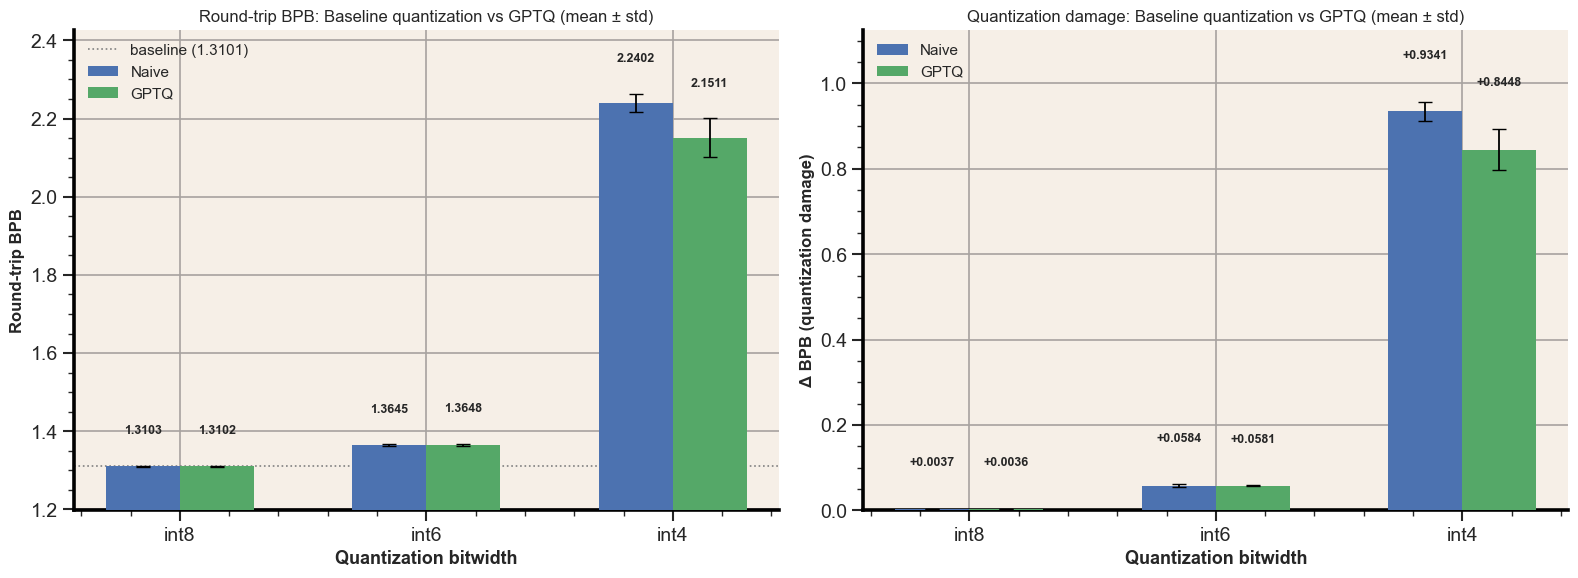

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bits_vals = [
    b for b in BITS_ORDER
    if b in stats_naive.index and b in stats_gptq.index
]

x = np.arange(len(bits_vals))
width = 0.3

# --- Round-trip BPB (mean ± std) ---
ax = axes[0]
bpb_naive = [stats_naive.loc[b, "final_val_bpb_mean"] for b in bits_vals]
bpb_naive_std = [stats_naive.loc[b, "final_val_bpb_std"] for b in bits_vals]
bpb_gptq = [stats_gptq.loc[b, "final_val_bpb_mean"] for b in bits_vals]
bpb_gptq_std = [stats_gptq.loc[b, "final_val_bpb_std"] for b in bits_vals]

bars1 = ax.bar(x - width/2, bpb_naive, width, label="Naive", color=NAIVE_COLOR, zorder=3)
bars2 = ax.bar(x + width/2, bpb_gptq,  width, label="GPTQ",  color=GPTQ_COLOR, zorder=3)

ax.errorbar(
    x - width/2, bpb_naive, yerr=bpb_naive_std, fmt="none",
    ecolor="black", elinewidth=1.3, capsize=5, zorder=4
)
ax.errorbar(
    x + width/2, bpb_gptq, yerr=bpb_gptq_std, fmt="none",
    ecolor="black", elinewidth=1.3, capsize=5, zorder=4
)

spread_bpb = max((bpb_naive + bpb_gptq), default=0) - min((bpb_naive + bpb_gptq), default=0)
pad_bpb = max(0.0002, 0.08 * spread_bpb)
for bar_group, vals, errs in [(bars1, bpb_naive, bpb_naive_std), (bars2, bpb_gptq, bpb_gptq_std)]:
    for bar, val, err in zip(bar_group, vals, errs):
        y = val + err + pad_bpb
        ax.text(bar.get_x() + bar.get_width()/2, y, f"{val:.4f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("Round-trip BPB: Baseline quantization vs GPTQ (mean ± std)", fontsize=12)
ax.legend(fontsize=11)

ymin = min([v - e for v, e in zip(bpb_naive, bpb_naive_std)] + [v - e for v, e in zip(bpb_gptq, bpb_gptq_std)], default=BASE_BPB_MEAN)
ymax = max([v + e for v, e in zip(bpb_naive, bpb_naive_std)] + [v + e for v, e in zip(bpb_gptq, bpb_gptq_std)], default=BASE_BPB_MEAN)
ax.set_ylim(ymin - pad_bpb * 1.5, ymax + pad_bpb * 2.2)

# --- Delta (quantization damage, mean ± std) ---
ax = axes[1]
delta_naive = [stats_naive.loc[b, "delta_bpb_mean"] for b in bits_vals]
delta_naive_std = [stats_naive.loc[b, "delta_bpb_std"] for b in bits_vals]
delta_gptq = [stats_gptq.loc[b, "delta_bpb_mean"] for b in bits_vals]
delta_gptq_std = [stats_gptq.loc[b, "delta_bpb_std"] for b in bits_vals]

bars1 = ax.bar(x - width/2, delta_naive, width, label="Naive", color=NAIVE_COLOR, zorder=3)
bars2 = ax.bar(x + width/2, delta_gptq,  width, label="GPTQ",  color=GPTQ_COLOR, zorder=3)

ax.errorbar(
    x - width/2, delta_naive, yerr=delta_naive_std, fmt="none",
    ecolor="black", elinewidth=1.3, capsize=5, zorder=4
)
ax.errorbar(
    x + width/2, delta_gptq, yerr=delta_gptq_std, fmt="none",
    ecolor="black", elinewidth=1.3, capsize=5, zorder=4
)

spread_delta = max((delta_naive + delta_gptq), default=0) - min((delta_naive + delta_gptq), default=0)
pad_delta = max(0.0002, 0.10 * spread_delta)
for bar_group, vals, errs in [(bars1, delta_naive, delta_naive_std), (bars2, delta_gptq, delta_gptq_std)]:
    for bar, val, err in zip(bar_group, vals, errs):
        if val >= 0:
            y = val + err + pad_delta
            va = "bottom"
        else:
            y = val - err - pad_delta
            va = "top"
        ax.text(bar.get_x() + bar.get_width()/2, y, f"{val:+.4f}",
                ha="center", va=va, fontsize=9, fontweight="bold")

ax.axhline(0.0, color="grey", linewidth=1.2, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Δ BPB (quantization damage)", fontsize=12)
ax.set_title("Quantization damage: Baseline quantization vs GPTQ (mean ± std)", fontsize=12)
ax.legend(fontsize=11)

ymax_d = max([v + e for v, e in zip(delta_naive, delta_naive_std)] + [v + e for v, e in zip(delta_gptq, delta_gptq_std)], default=0.0)
ax.set_ylim(0.0, ymax_d + pad_delta * 1.8)

plt.tight_layout(pad=1.5)
plt.show()

### Compressed file size comparison

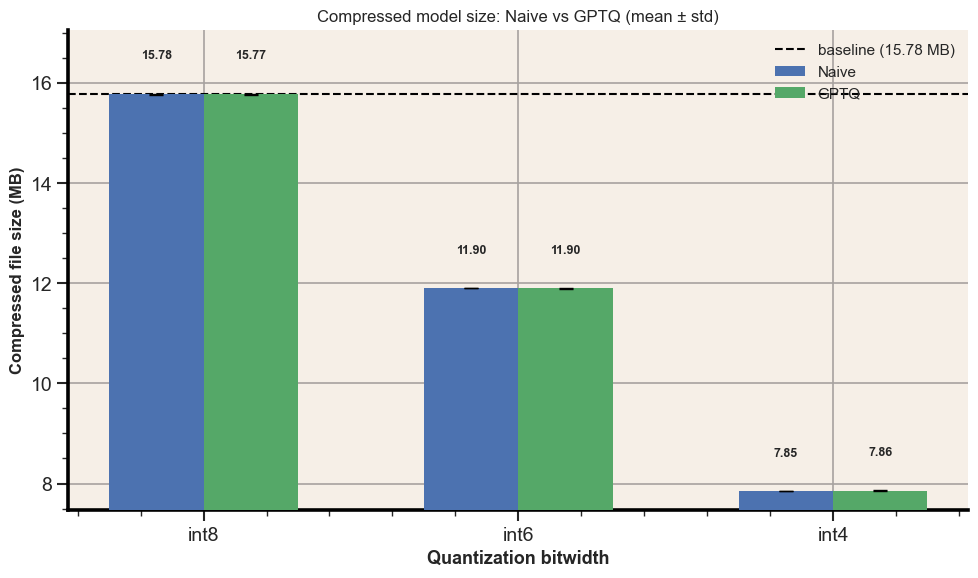

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

bits_vals = [
    b for b in BITS_ORDER
    if b in stats_naive.index and b in stats_gptq.index
]
x = np.arange(len(bits_vals))
width = 0.3

size_naive = [stats_naive.loc[b, "quant_file_mb_mean"] for b in bits_vals]
size_naive_std = [stats_naive.loc[b, "quant_file_mb_std"] for b in bits_vals]
size_gptq = [stats_gptq.loc[b, "quant_file_mb_mean"] for b in bits_vals]
size_gptq_std = [stats_gptq.loc[b, "quant_file_mb_std"] for b in bits_vals]

bars1 = ax.bar(x - width/2, size_naive, width, label="Naive", color=NAIVE_COLOR, zorder=3)
bars2 = ax.bar(x + width/2, size_gptq,  width, label="GPTQ",  color=GPTQ_COLOR, zorder=3)

ax.errorbar(
    x - width/2, size_naive, yerr=size_naive_std, fmt="none",
    ecolor="black", elinewidth=1.3, capsize=5, zorder=4
)
ax.errorbar(
    x + width/2, size_gptq, yerr=size_gptq_std, fmt="none",
    ecolor="black", elinewidth=1.3, capsize=5, zorder=4
)

spread = max((size_naive + size_gptq), default=0) - min((size_naive + size_gptq), default=0)
pad = max(0.02, 0.08 * spread)
for bar_group, sizes, errs in [(bars1, size_naive, size_naive_std), (bars2, size_gptq, size_gptq_std)]:
    for bar, mb, err in zip(bar_group, sizes, errs):
        y = mb + err + pad
        ax.text(bar.get_x() + bar.get_width()/2, y, f"{mb:.2f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(BASE_SIZE_MEAN / 1e6, color="black", linewidth=1.5, linestyle="--",
           label=f"baseline ({BASE_SIZE_MEAN / 1e6:.2f} MB)")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Compressed file size (MB)", fontsize=12)
ax.set_title("Compressed model size: Naive vs GPTQ (mean ± std)", fontsize=12)
ax.legend(fontsize=11, loc="upper right")

ymin = min([v - e for v, e in zip(size_naive, size_naive_std)] + [v - e for v, e in zip(size_gptq, size_gptq_std)], default=0.0)
ymax = max([v + e for v, e in zip(size_naive, size_naive_std)] + [v + e for v, e in zip(size_gptq, size_gptq_std)], default=0.0)
ax.set_ylim(ymin - pad * 0.6, ymax + pad * 2.0)

plt.tight_layout(pad=1.5)
plt.show()

### Tradeoff: BPB vs compressed size

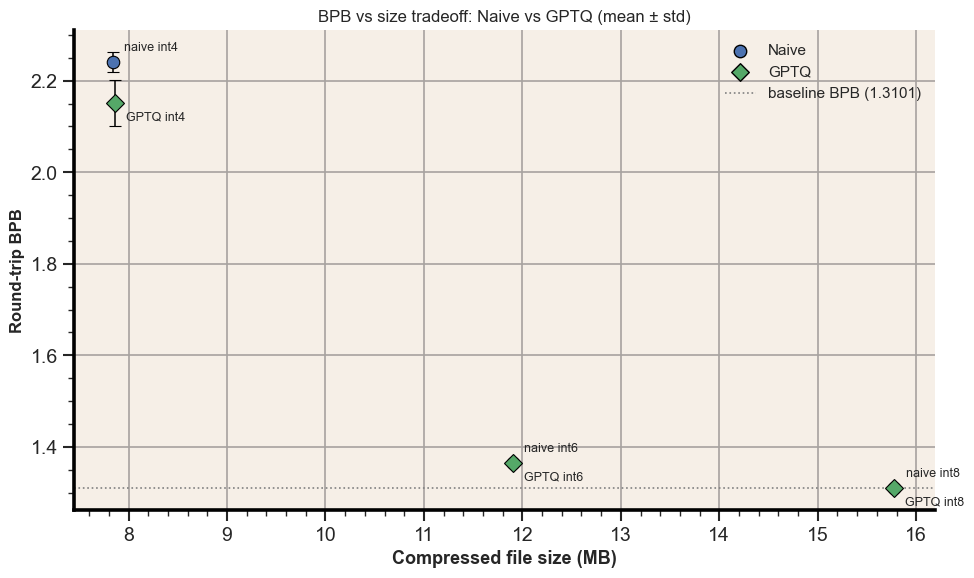

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

bits_vals = [
    b for b in BITS_ORDER
    if b in stats_naive.index and b in stats_gptq.index
]

for b in bits_vals:
    # Naive point (mean ± std in both axes)
    row_n = stats_naive.loc[b]
    x_n, y_n = row_n["quant_file_mb_mean"], row_n["final_val_bpb_mean"]
    xerr_n, yerr_n = row_n["quant_file_mb_std"], row_n["final_val_bpb_std"]
    ax.errorbar(
        x_n, y_n, xerr=xerr_n, yerr=yerr_n,
        fmt="o", color=NAIVE_COLOR, markersize=9,
        ecolor="black", elinewidth=1.1, capsize=4,
        markeredgecolor="black", markeredgewidth=0.8, zorder=5
    )
    ax.annotate(f"naive {BITS_LABELS[b]}",
                (x_n, y_n), textcoords="offset points", xytext=(8, 8), fontsize=9)

    # GPTQ point (mean ± std in both axes)
    row_g = stats_gptq.loc[b]
    x_g, y_g = row_g["quant_file_mb_mean"], row_g["final_val_bpb_mean"]
    xerr_g, yerr_g = row_g["quant_file_mb_std"], row_g["final_val_bpb_std"]
    ax.errorbar(
        x_g, y_g, xerr=xerr_g, yerr=yerr_g,
        fmt="D", color=GPTQ_COLOR, markersize=9,
        ecolor="black", elinewidth=1.1, capsize=4,
        markeredgecolor="black", markeredgewidth=0.8, zorder=5
    )
    ax.annotate(f"GPTQ {BITS_LABELS[b]}",
                (x_g, y_g), textcoords="offset points", xytext=(8, -12), fontsize=9)

# Add legend entries
ax.scatter([], [], color=NAIVE_COLOR, s=80, marker="o", edgecolors="black", label="Naive")
ax.scatter([], [], color=GPTQ_COLOR,  s=80, marker="D", edgecolors="black", label="GPTQ")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline BPB ({BASE_BPB_MEAN:.4f})")

ax.set_xlabel("Compressed file size (MB)", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("BPB vs size tradeoff: Naive vs GPTQ (mean ± std)", fontsize=12)
ax.legend(fontsize=11, loc="upper right")
plt.tight_layout(pad=1.5)
plt.show()

### GPTQ improvement over Naive at each bitwidth

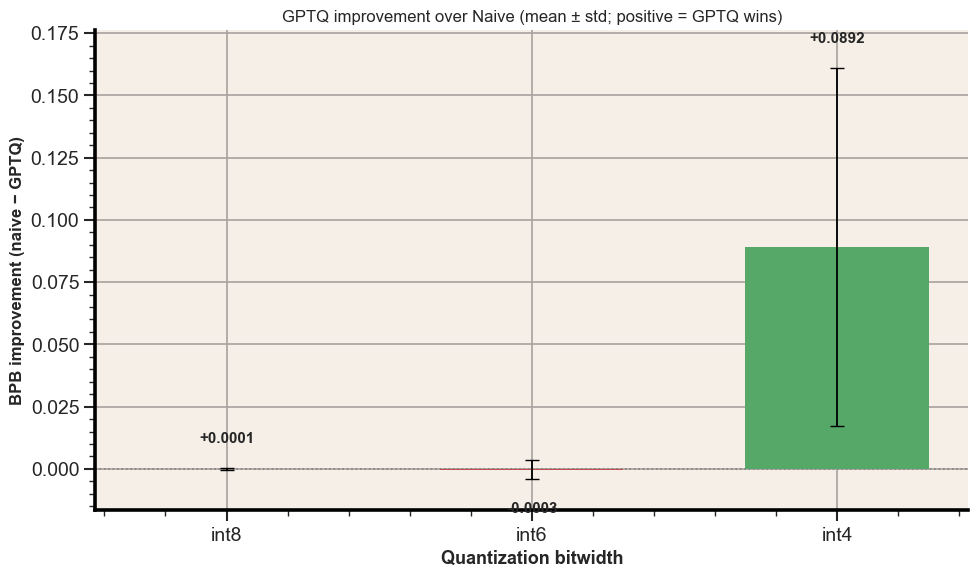

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

bits_vals = [
    b for b in BITS_ORDER
    if b in stats_naive.index and b in stats_gptq.index
]

improvements_mean = []
improvements_std = []
for b in bits_vals:
    # Prefer seed-aligned std of (naive - GPTQ) when overlapping seeds exist.
    n = df_naive[df_naive["quant_bits"] == b][["seed", "final_val_bpb"]].rename(
        columns={"final_val_bpb": "naive_bpb"}
    )
    g = df_gptq[df_gptq["quant_bits"] == b][["seed", "final_val_bpb"]].rename(
        columns={"final_val_bpb": "gptq_bpb"}
    )
    paired = n.merge(g, on="seed", how="inner")

    imp_mean = stats_naive.loc[b, "final_val_bpb_mean"] - stats_gptq.loc[b, "final_val_bpb_mean"]
    improvements_mean.append(imp_mean)

    if len(paired) >= 2:
        imp_std = (paired["naive_bpb"] - paired["gptq_bpb"]).std(ddof=1)
        imp_std = 0.0 if pd.isna(imp_std) else float(imp_std)
    else:
        imp_std = float(np.sqrt(
            stats_naive.loc[b, "final_val_bpb_std"]**2 + stats_gptq.loc[b, "final_val_bpb_std"]**2
        ))
    improvements_std.append(imp_std)

colors = [GPTQ_COLOR if imp > 0 else PALETTE[3] for imp in improvements_mean]
x = np.arange(len(bits_vals))
ax.bar(x, improvements_mean, color=colors, width=0.6, zorder=3)
ax.errorbar(
    x, improvements_mean, yerr=improvements_std, fmt="none",
    ecolor="black", elinewidth=1.3, capsize=5, zorder=4
)

spread = max(improvements_mean, default=0.0) - min(improvements_mean, default=0.0)
pad = max(0.0002, 0.10 * spread)
for i, (imp, err) in enumerate(zip(improvements_mean, improvements_std)):
    if imp >= 0:
        y, va = imp + err + pad, "bottom"
    else:
        y, va = imp - err - pad, "top"
    ax.text(i, y, f"{imp:+.4f}", ha="center", va=va, fontsize=11, fontweight="bold")

ax.axhline(0.0, color="grey", linewidth=1.2, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("BPB improvement (naive − GPTQ)", fontsize=12)
ax.set_title("GPTQ improvement over Naive (mean ± std; positive = GPTQ wins)", fontsize=12)

ymin = min([v - e for v, e in zip(improvements_mean, improvements_std)], default=0.0)
ymax = max([v + e for v, e in zip(improvements_mean, improvements_std)], default=0.0)
ax.set_ylim(ymin - pad * 1.4, ymax + pad * 1.7)

plt.tight_layout(pad=1.5)
plt.show()

### Summary table

In [14]:
rows_summary = [{
    "config":          "Original baseline (3 seeds)",
    "method":          "—",
    "n_seeds":         len(df_base),
    "val_bpb":         BASE_BPB_MEAN,
    "val_bpb_std":     BASE_BPB_STD,
    "delta_bpb":       float("nan"),
    "delta_bpb_std":   float("nan"),
    "Δ vs baseline":   0.0,
    "file_size_MB":    BASE_SIZE_MEAN / 1e6,
    "file_size_std":   std_or_zero(df_base["quant_file_bytes"]) / 1e6,
}]

for b in BITS_ORDER:
    # Naive
    if b in stats_naive.index:
        row = stats_naive.loc[b]
        rows_summary.append({
            "config":         f"{BITS_LABELS[b]}",
            "method":         "naive",
            "n_seeds":        int(row["n_seeds"]),
            "val_bpb":        row["final_val_bpb_mean"],
            "val_bpb_std":    row["final_val_bpb_std"],
            "delta_bpb":      row["delta_bpb_mean"],
            "delta_bpb_std":  row["delta_bpb_std"],
            "Δ vs baseline":  row["final_val_bpb_mean"] - BASE_BPB_MEAN,
            "file_size_MB":   row["quant_file_mb_mean"],
            "file_size_std":  row["quant_file_mb_std"],
        })

    # GPTQ
    if b in stats_gptq.index:
        row = stats_gptq.loc[b]
        rows_summary.append({
            "config":         f"{BITS_LABELS[b]}",
            "method":         "GPTQ",
            "n_seeds":        int(row["n_seeds"]),
            "val_bpb":        row["final_val_bpb_mean"],
            "val_bpb_std":    row["final_val_bpb_std"],
            "delta_bpb":      row["delta_bpb_mean"],
            "delta_bpb_std":  row["delta_bpb_std"],
            "Δ vs baseline":  row["final_val_bpb_mean"] - BASE_BPB_MEAN,
            "file_size_MB":   row["quant_file_mb_mean"],
            "file_size_std":  row["quant_file_mb_std"],
        })

df_summary = pd.DataFrame(rows_summary)
df_summary["val_bpb"]       = df_summary["val_bpb"].map(lambda x: f"{x:.4f}")
df_summary["val_bpb_std"]   = df_summary["val_bpb_std"].map(lambda x: f"±{x:.4f}" if not np.isnan(x) else "—")
df_summary["delta_bpb"]     = df_summary["delta_bpb"].map(lambda x: f"{x:+.4f}" if not np.isnan(x) else "—")
df_summary["delta_bpb_std"] = df_summary["delta_bpb_std"].map(lambda x: f"±{x:.4f}" if not np.isnan(x) else "—")
df_summary["Δ vs baseline"] = df_summary["Δ vs baseline"].map(lambda x: f"{x:+.4f}")
df_summary["file_size_MB"]  = df_summary["file_size_MB"].map(lambda x: f"{x:.2f}")
df_summary["file_size_std"] = df_summary["file_size_std"].map(lambda x: f"±{x:.2f}" if not np.isnan(x) else "—")

print(df_summary.to_string(index=False))

# Key findings
print("\n" + "=" * 70)
for b in bits_vals:
    imp = stats_naive.loc[b, "final_val_bpb_mean"] - stats_gptq.loc[b, "final_val_bpb_mean"]
    print(f"{BITS_LABELS[b]}: GPTQ {'improves' if imp > 0 else 'worsens'} BPB by {abs(imp):.4f}")

# Cross-bitwidth comparison
print("\n--- Cross-bitwidth comparison ---")
if 8 in stats_naive.index and 6 in stats_gptq.index:
    naive8_bpb = stats_naive.loc[8, "final_val_bpb_mean"]
    gptq6_bpb  = stats_gptq.loc[6, "final_val_bpb_mean"]
    naive8_size = stats_naive.loc[8, "quant_file_mb_mean"]
    gptq6_size  = stats_gptq.loc[6, "quant_file_mb_mean"]
    diff = naive8_bpb - gptq6_bpb
    print(f"Naive int8: {naive8_bpb:.4f} BPB, {naive8_size:.2f} MB")
    print(f"GPTQ  int6: {gptq6_bpb:.4f} BPB, {gptq6_size:.2f} MB")
    if diff > 0:
        print(f"→ GPTQ int6 beats naive int8 by {diff:.4f} BPB while being {naive8_size - gptq6_size:.2f} MB smaller!")
    else:
        print(f"→ GPTQ int6 is {-diff:.4f} BPB worse than naive int8, but {naive8_size - gptq6_size:.2f} MB smaller.")

                     config method  n_seeds val_bpb val_bpb_std delta_bpb delta_bpb_std Δ vs baseline file_size_MB file_size_std
Original baseline (3 seeds)      —        3  1.3101     ±0.0013         —             —       +0.0000        15.78         ±0.00
                       int8  naive        3  1.3103     ±0.0013   +0.0037       ±0.0001       +0.0002        15.78         ±0.01
                       int8   GPTQ        3  1.3102     ±0.0010   +0.0036       ±0.0000       +0.0001        15.77         ±0.01
                       int6  naive        3  1.3645     ±0.0019   +0.0584       ±0.0026       +0.0544        11.90         ±0.00
                       int6   GPTQ        3  1.3648     ±0.0025   +0.0581       ±0.0013       +0.0547        11.90         ±0.01
                       int4  naive        3  2.2402     ±0.0225   +0.9341       ±0.0231       +0.9301         7.85         ±0.00
                       int4   GPTQ        3  2.1511     ±0.0494   +0.8448       ±0.0488       +0.